In [18]:
!pip install -r requirements.txt

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import joblib


### 1. Loading and Exploring Data

In [20]:
df = pd.read_csv("../EDA/data/processed/ChurnModeling_Binning_Applied.csv")
df.head()

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScoreBins
0,France,Female,42.00,2,0.00,1,1,1,101348.88,1,Fair
1,Spain,Female,41.00,1,83807.86,1,0,1,112542.58,0,Fair
2,France,Female,42.00,8,159660.80,3,1,0,113931.57,1,Poor
3,France,Female,38.91,1,0.00,2,0,0,93826.63,0,Good
4,Spain,Female,43.00,2,125510.82,1,1,1,79084.10,0,Excellent


### 2. Build Scikit-learn Pipeline

In [21]:
remainder_features = ['NumOfProducts', 'HasCrCard', "IsActiveMember", "Exited"]
numerical_features = ['Age', 'Tenure', 'Balance', 'EstimatedSalary']
nominal_features = ["Gender", "Geography"] # One-Hot Encoding
ordinal_features = ["CreditScoreBins"] # Label Encoding

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='median')),
        ('scalar', StandardScaler())
    ]
)

nominal_tranformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder())
    ]
)

ordinal_transformer = Pipeline(
    steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OrdinalEncoder())
        ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('nom', nominal_tranformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],
    remainder='drop'
)

In [22]:
nominal_feature_names = []
for feature in nominal_features:
    unique_values  = df[feature].unique()
    nominal_feature_names.extend(f"{feature}_{val}" for val in unique_values)

df_cp = df.copy()
df_transformed = pd.DataFrame(preprocessor.fit_transform(df_cp),
    columns = numerical_features + nominal_feature_names + ordinal_features
)

df_transformed

,Age,Tenure,Balance,EstimatedSalary,Gender_Female,Gender_Male,Geography_France,Geography_Spain,Geography_Germany,CreditScoreBins
0,0.302983,-1.041760,-1.225848,0.021886,1.0,0.0,1.0,0.0,0.0,1.0
1,0.204867,-1.387538,0.117350,0.216534,1.0,0.0,0.0,0.0,1.0,1.0
2,0.302983,1.032908,1.333053,0.240687,1.0,0.0,1.0,0.0,0.0,3.0
3,-0.000196,-1.387538,-1.225848,-0.108918,1.0,0.0,1.0,0.0,0.0,2.0
4,0.401100,-1.041760,0.785728,-0.365276,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
9995,0.008634,-0.004426,-1.225848,-0.066419,0.0,1.0,1.0,0.0,0.0,4.0
9996,-0.383831,1.724464,-0.306379,0.027988,0.0,1.0,1.0,0.0,0.0,3.0
9997,-0.285715,0.687130,-1.225848,-1.008643,1.0,0.0,1.0,0.0,0.0,2.0
9998,0.302983,-0.695982,-0.022608,-0.125231,0.0,1.0,0.0,1.0,0.0,4.0


In [23]:
df_remainder = df[remainder_features]
df_pp = pd.concat([df_remainder, df_transformed], axis=1)
df_pp

,NumOfProducts,HasCrCard,IsActiveMember,Exited,Age,Tenure,Balance,EstimatedSalary,Gender_Female,Gender_Male,Geography_France,Geography_Spain,Geography_Germany,CreditScoreBins
0,1,1,1,1,0.302983,-1.041760,-1.225848,0.021886,1.0,0.0,1.0,0.0,0.0,1.0
1,1,0,1,0,0.204867,-1.387538,0.117350,0.216534,1.0,0.0,0.0,0.0,1.0,1.0
2,3,1,0,1,0.302983,1.032908,1.333053,0.240687,1.0,0.0,1.0,0.0,0.0,3.0
3,2,0,0,0,-0.000196,-1.387538,-1.225848,-0.108918,1.0,0.0,1.0,0.0,0.0,2.0
4,1,1,1,0,0.401100,-1.041760,0.785728,-0.365276,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,1,0,0,0.008634,-0.004426,-1.225848,-0.066419,0.0,1.0,1.0,0.0,0.0,4.0
9996,1,1,1,0,-0.383831,1.724464,-0.306379,0.027988,0.0,1.0,1.0,0.0,0.0,3.0
9997,1,0,1,1,-0.285715,0.687130,-1.225848,-1.008643,1.0,0.0,1.0,0.0,0.0,2.0
9998,2,1,0,1,0.302983,-0.695982,-0.022608,-0.125231,0.0,1.0,0.0,1.0,0.0,4.0


In [24]:
df_pp.to_csv("../EDA/data/processed/X_Transformed.csv", index=False)

### 3. Handle Class Imbalance

In [25]:
X = df_pp.drop(columns=['Exited'])
Y = df_pp['Exited']

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [28]:
smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

Text(0, 0.5, 'Count')

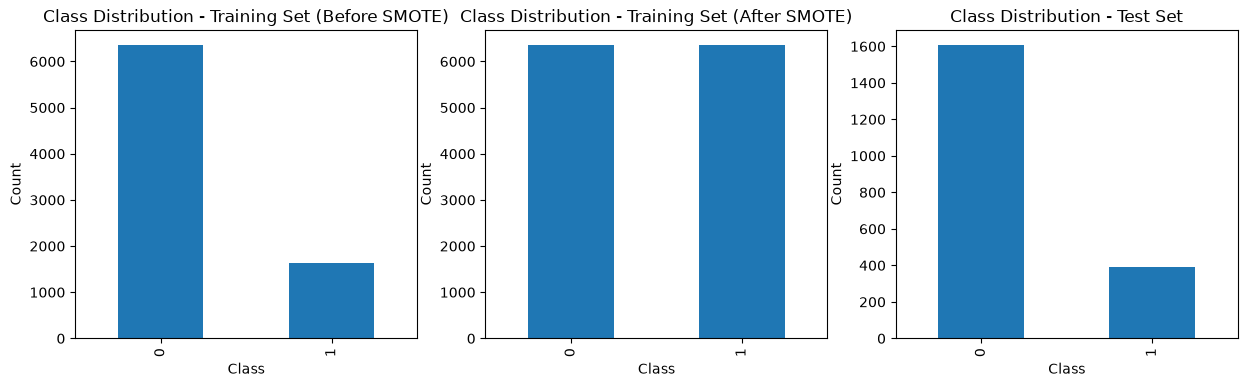

In [29]:
plt.figure(figsize=(15,4))

plt.subplot(131)
Y_train.value_counts().plot(kind='bar')
plt.title("Class Distribution - Training Set (Before SMOTE)")
plt.xlabel("Class")
plt.ylabel('Count')

plt.subplot(132)
Y_train_resampled.value_counts().plot(kind='bar')
plt.title("Class Distribution - Training Set (After SMOTE)")
plt.xlabel("Class")
plt.ylabel('Count')

plt.subplot(133)
Y_test.value_counts().plot(kind='bar')
plt.title("Class Distribution - Test Set")
plt.xlabel("Class")
plt.ylabel('Count')

In [32]:
np.savez('artifacts/X_train.npz', X_train_resampled)
np.savez('artifacts/Y_train.npz', Y_train_resampled)
np.savez('artifacts/X_test.npz', X_test)
np.savez('artifacts/Y_test.npz', Y_test)